# [LAB-02] 4. 페르소나 분석

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, crosstab
import joblib

# 정규성 검정
from scipy.stats import normaltest

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기

In [2]:
origin = load_data("mall_customers")
origin.head()

📚 이 데이터 세트는 쇼핑몰 고객의 인구통계학적 특성과 소비 습관에 대한 정보를 담고 있습니다. 고객 ID, 성별, 나이, 연간 소득, 지출 점수와 같은 다양한 속성이 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/shwetabh123/mall-customers)


,고객ID,성별,나이,연수입,지출점수
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3. 데이터 전처리 - 변수 타입 정리

`성별` 은 문자열이지만 의미상 **범주형**이다. 타입을 지정해 두면 뒤에서 연속형/범주형을 자동으로 구분할 수 있다.

In [3]:
origin = my_qtcheck.set_type(origin, as_category=["성별"])

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   고객ID    200 non-null    int64   
 1   성별      200 non-null    category
 2   나이      200 non-null    int64   
 3   연수입     200 non-null    int64   
 4   지출점수    200 non-null    int64   
dtypes: category(1), int64(4)
memory usage: 6.6 KB


### 4. 군집화에 사용할 변수 선택

In [4]:
df = origin[["연수입", "지출점수"]]
df.head()

,연수입,지출점수
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### 5. 데이터 스케일링

In [5]:
# save_path 를 지정하면 학습된 스케일러가 파일로 저장된다
# --> 신규 고객을 '똑같은 기준'으로 변환할 때 다시 불러 쓴다
sdf = my_prep.scaling(df, method="standard", 
                      save_path="models/mall_scaler.pkl")
sdf.head()

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
연수입               15.00 ~ 137.00          -1.74 ~ 2.92
지출점수                1.00 ~ 99.00          -1.91 ~ 1.89

스케일러 저장: models/mall_scaler.pkl (StandardScaler)


,연수입,지출점수
0,-1.739,-0.435
1,-1.739,1.196
2,-1.701,-1.716
3,-1.701,1.040
4,-1.663,-0.396


## #02. 군집 모형 적합

### 1. 군집수 확정

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
연수입               15.00 ~ 137.00          -1.74 ~ 2.92
지출점수                1.00 ~ 99.00          -1.91 ~ 1.89


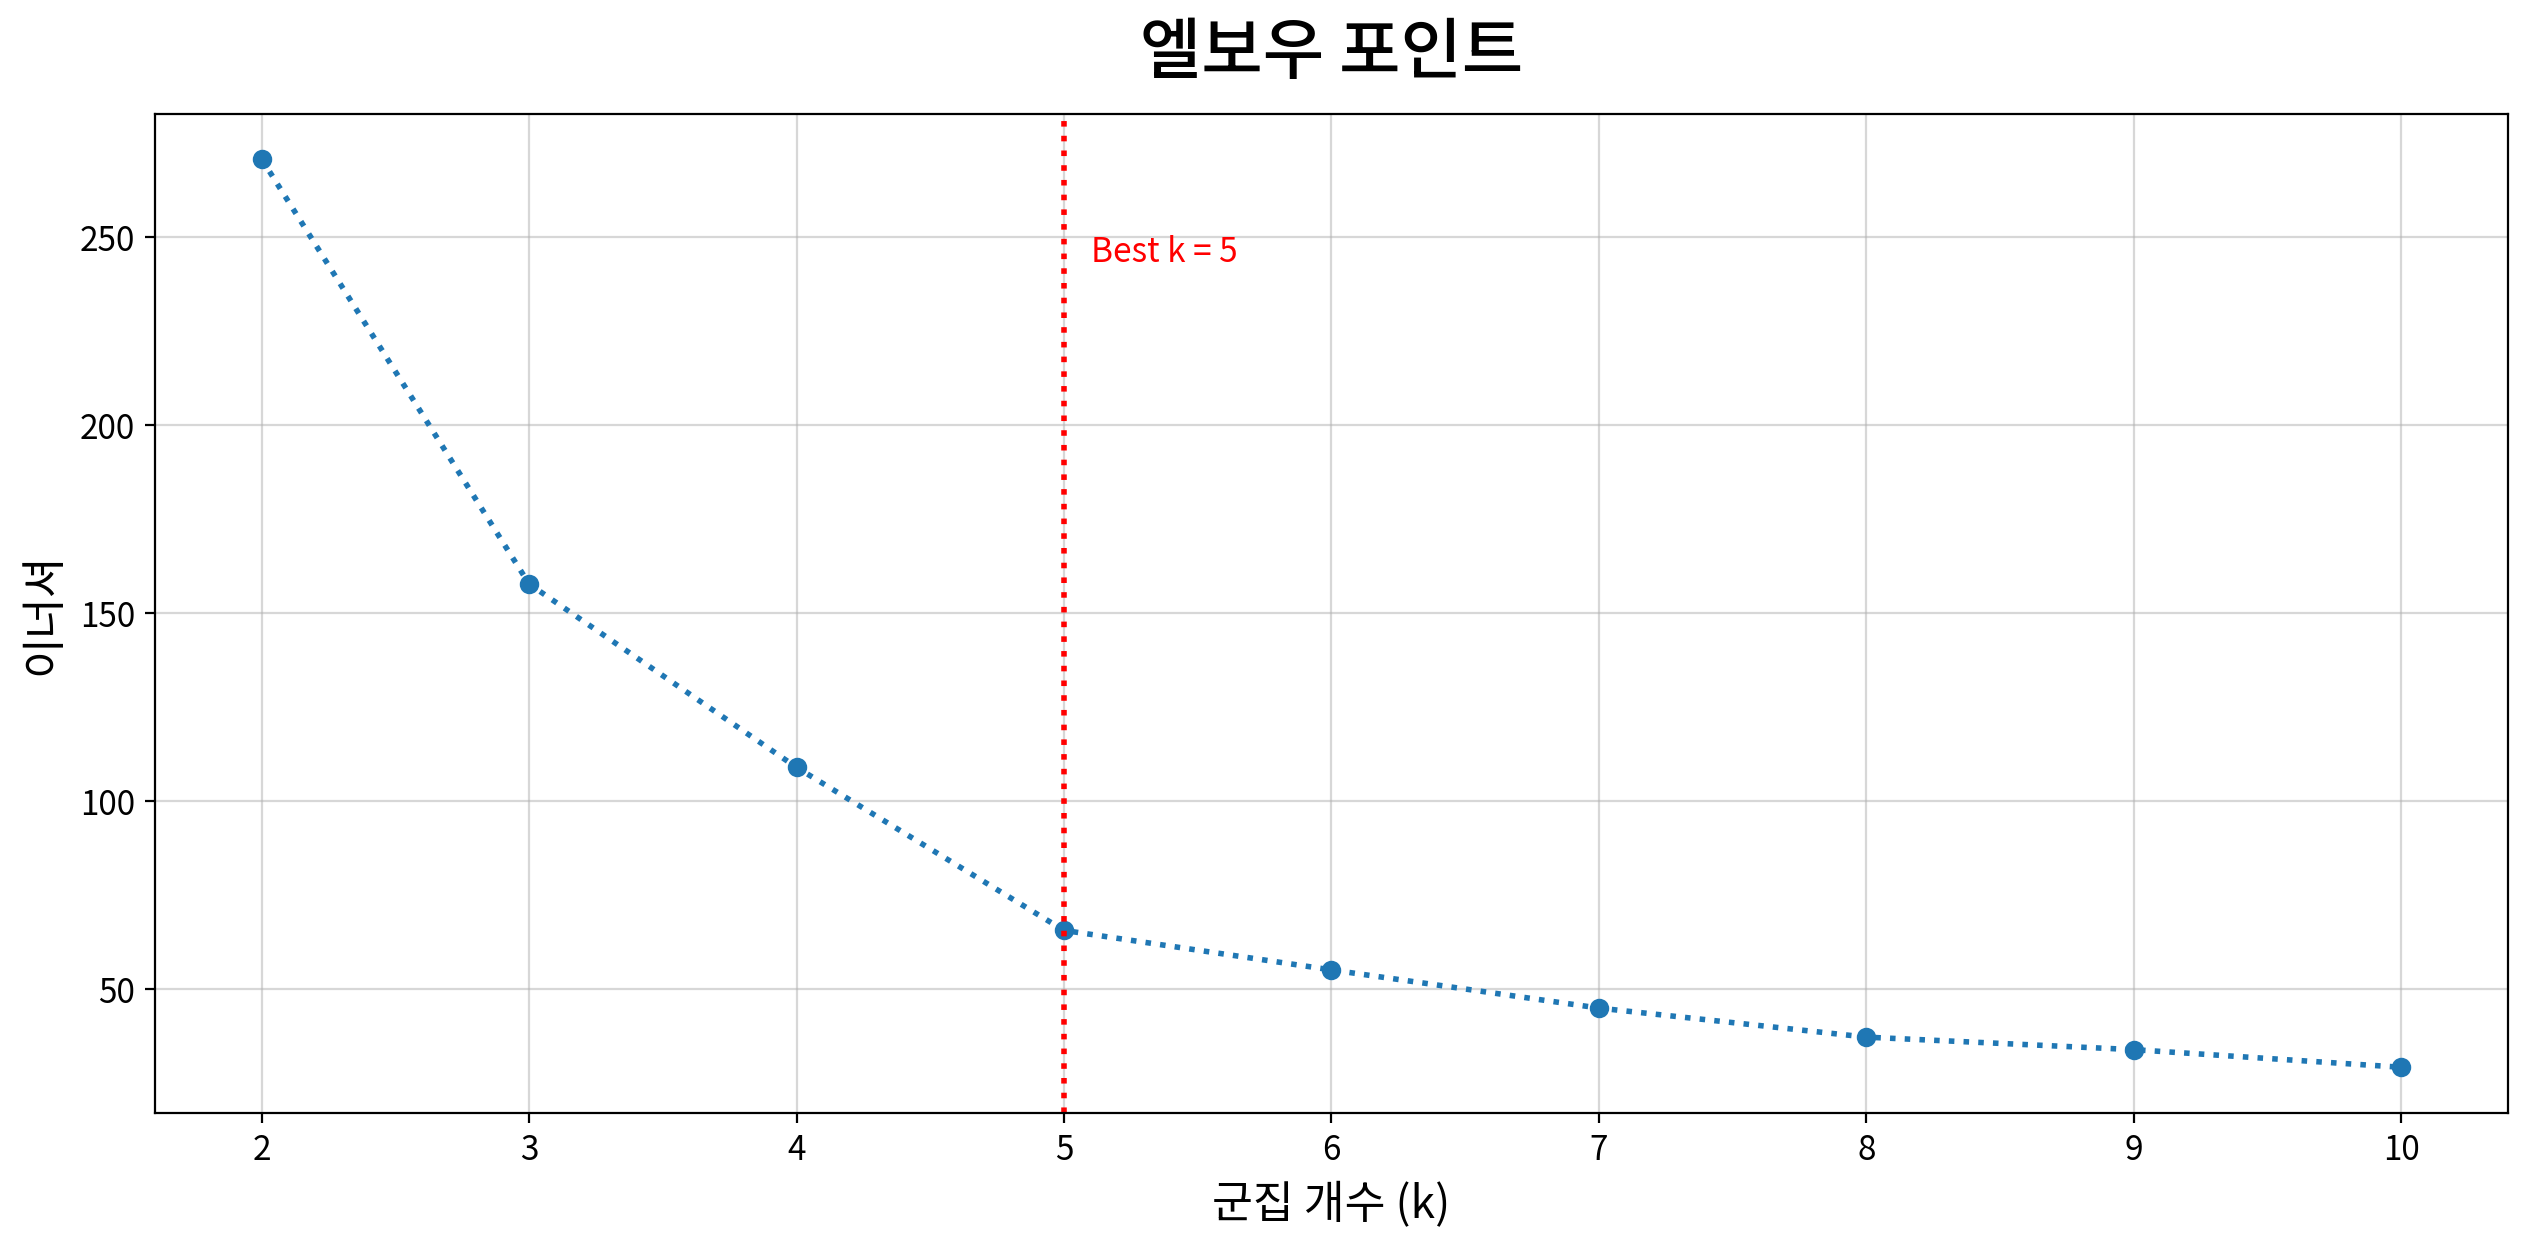

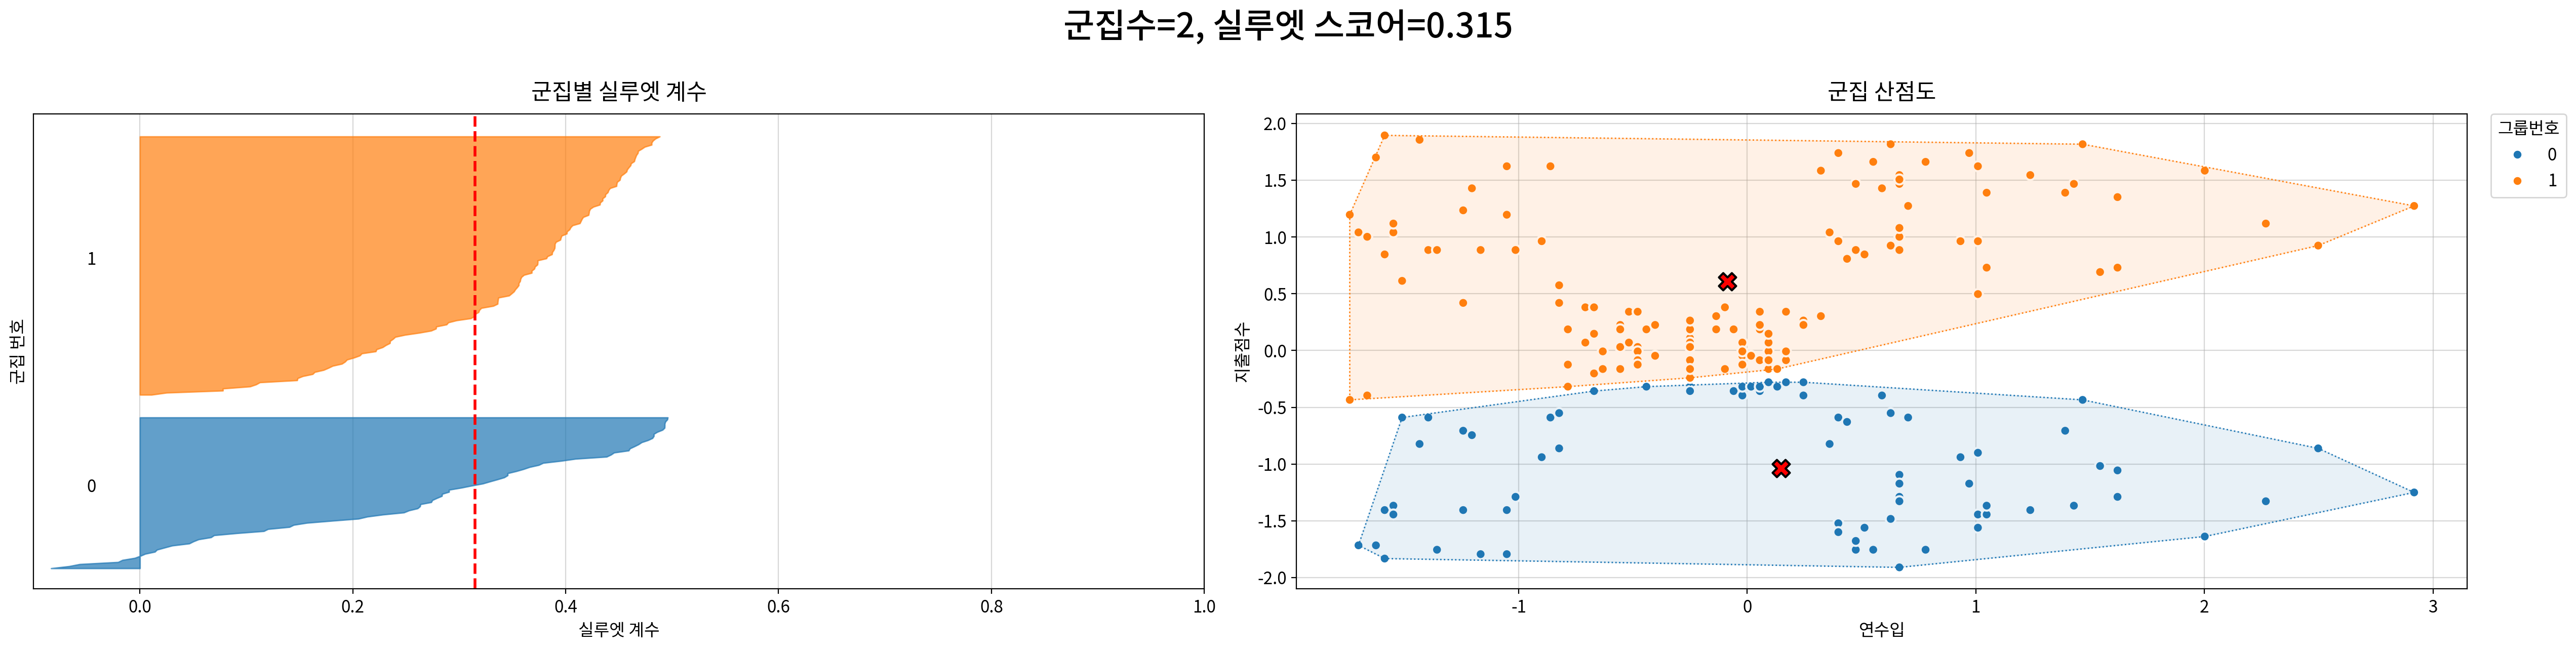

[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
  · k = 5 : 균형지수 0.0797 (스코어 0.5547, 두께비 3.6818)
  · k = 2 : 균형지수 0.1162 (스코어 0.3147, 두께비 1.7027)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,270.704,NaN,0.315,62.940,1.703,0.628,0.116
1,3,157.704,113.000,0.467,93.317,3.237,0.685,0.099
2,4,108.921,48.783,0.494,98.781,4.348,0.516,0.059
3,5,65.568,43.353,0.555,110.931,3.682,0.529,0.080
4,6,55.057,10.511,0.540,107.976,8.100,0.182,0.012
5,7,44.911,10.146,0.526,105.269,7.900,0.227,0.015
6,8,37.182,7.729,0.456,91.240,4.300,0.287,0.030
7,9,33.854,3.328,0.455,91.058,6.125,0.301,0.022
8,10,29.167,4.687,0.448,89.634,6.571,0.262,0.018


In [6]:
final_k, result_df = my_cluster.best_k(df, verbose=True)
result_df

**`2`** 가 나온다.

> 이 함수가 쓰는 **균형지수**는 스코어를 `두께비`(가장 큰 군집 ÷ 가장 작은 군집)로 나눠 깎는데,
> **군집 크기가 원래 고른 데이터**(예: 붓꽃 품종별 50송이)를 전제로 만든 지표이기 때문이다.
>
> 고객 데이터는 **중간층이 두껍고 극단 집단이 얇은 것이 정상**이다. 이건 데이터의 결함이 아니라 시장의 실제 모습이다.
> 그래서 이 데이터에서는 두께비 페널티가 과도해진다.
>
> **지표는 데이터의 성격에 맞는 것을 골라 써야 한다.** 어떤 지표도 모든 데이터에 일괄적으로 통하지는 않는다. (도메인 지식의 중요성)

### 2. 최적 k 결정

- 구매·사용량 기준으로 고객층을 신규 구매 고객, 간헐적 구매 고객, 반복 구매 고객, 정기·고빈도 구매 고객, 대량 구매 고객의 5개 층으로 나눌 수 있다(ZDF Werbefernsehen GmbH. 2025).
- 이는 엘보우 포인트가 제시한 k값과도 일치하므로 최적의 k값을 5로 채택함

In [7]:
best_k = 5

### 3. 모형 적합

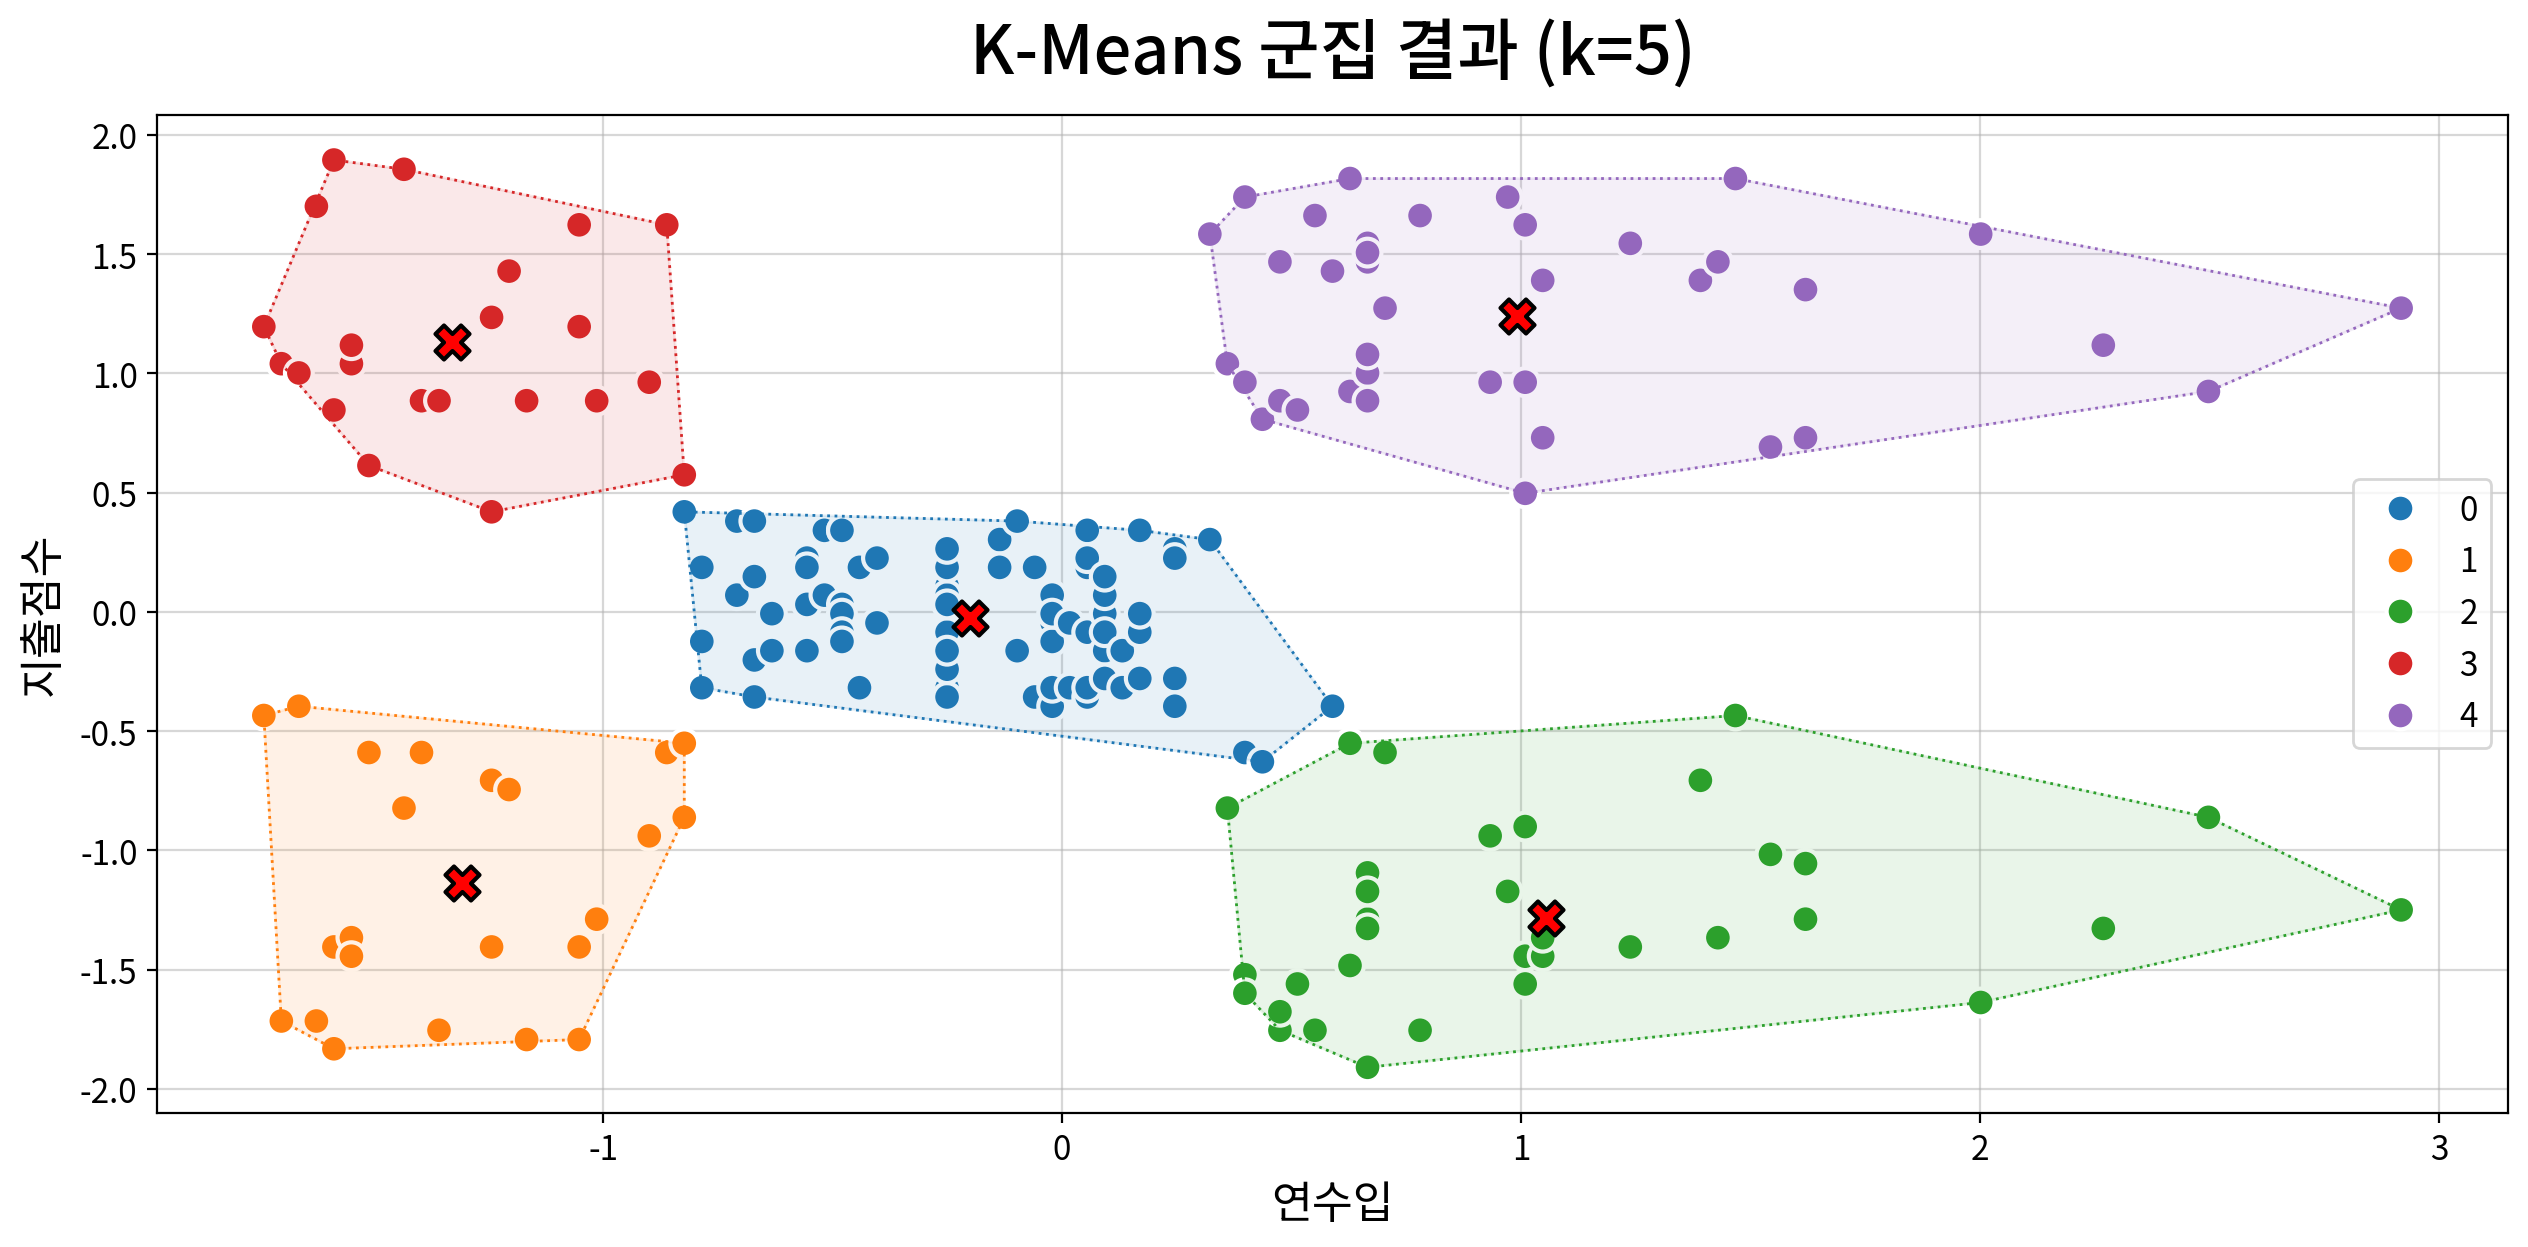

In [8]:
# my_cluster.kmeans() 가 학습 → 군집 번호 부여 → 중심점 정리까지 한 번에 처리한다
estimator, cdf, center_df = my_cluster.kmeans(df, k=best_k, 
                            cluster_name="ClusterID", verbose=False)

### 4. 군집 형태 확인

- 앞서 확인한 그래프의 축은 **원본 값**을 쓴다. 
  - 스케일링된 값(`-1.2`, `0.8` ...)으로 그리면 "연수입 80" 처럼 실제 수치를 읽을 수 없기 때문에 원본 데이터를 통해 확인한다.

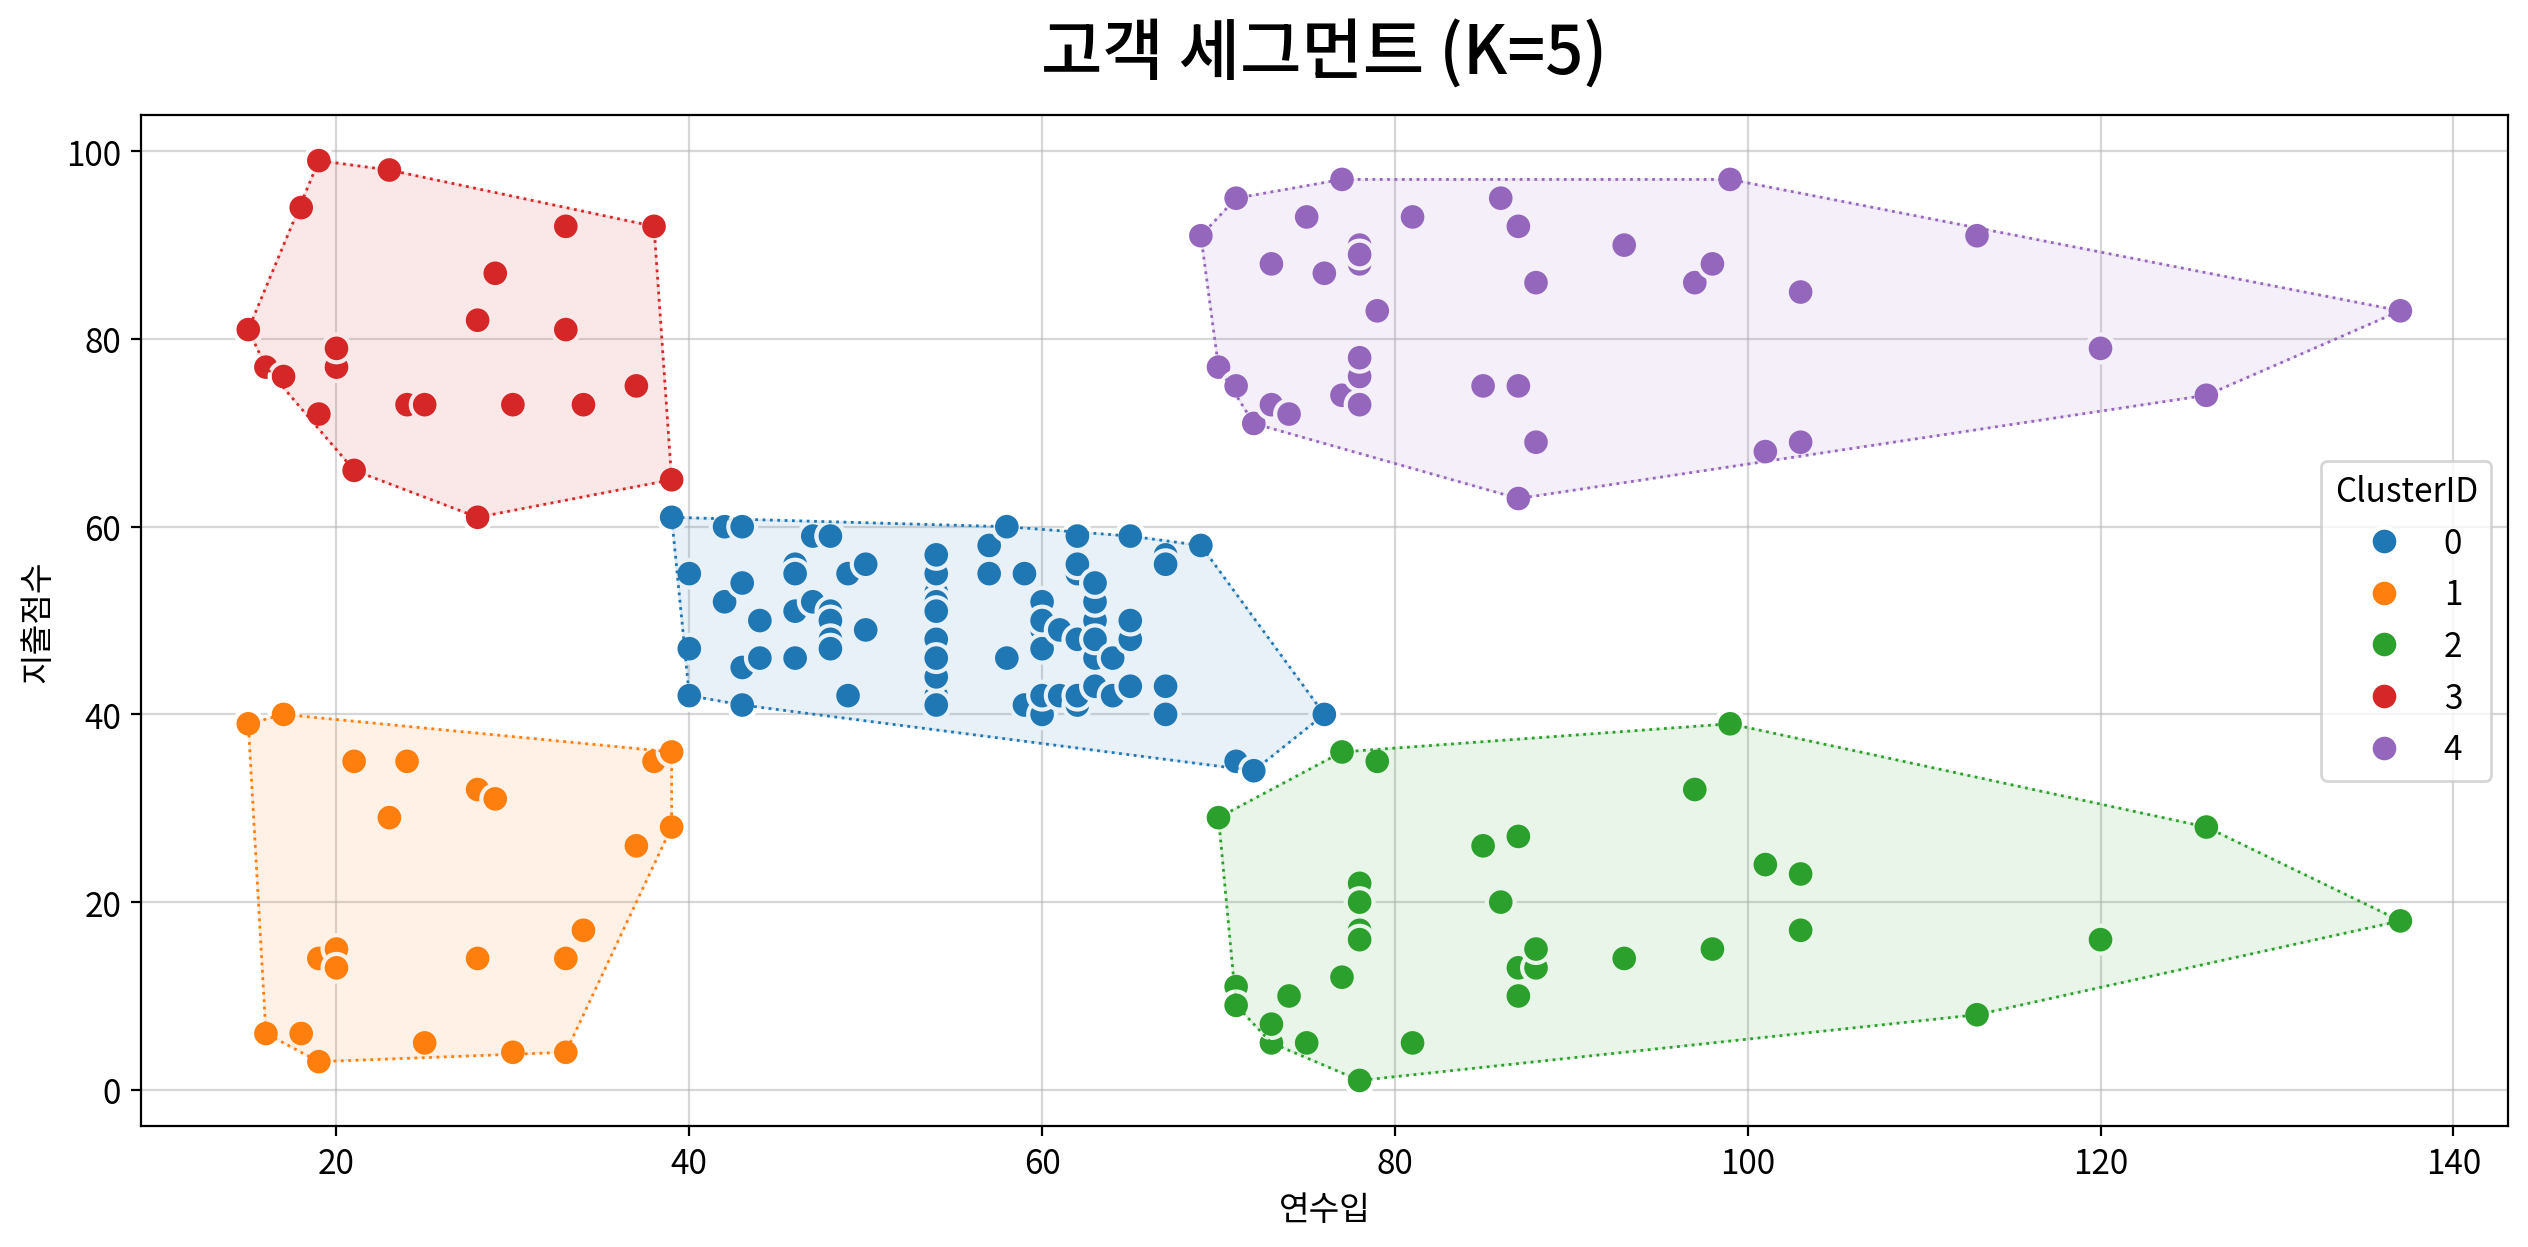

In [ ]:
vdf = df.copy()                         # 원본 데이터 복사
vdf["ClusterID"] = estimator.labels_    # 복사한 원본에 군집 번호 컬럼 추가

my_plot.scatterplot(data=vdf, x="연수입", y="지출점수", hue="ClusterID", 
                    title=f"고객 세그먼트 (K={best_k})")

#### 💡 인사이트

**네 모서리 + 가운데** — 주사위의 5 눈 같은 배치다.

`연수입` 과 `지출점수` 가 서로 **독립적으로** 움직이기 때문에 이런 모양이 나온다.
소득이 높다고 많이 쓰는 것도 아니고, 소득이 낮다고 적게 쓰는 것도 아니다.

## #03. 페르소나 도출

### 1. 원본 데이터에 군집 번호 붙이기

- **학습은 스케일링된 데이터로, 해석은 원본 데이터로 한다.**
  - 스케일링된 값(`-1.2`, `0.8` ...)은 사람이 읽을 수 없기 때문

In [12]:
pdf = origin.copy()
pdf["ClusterID"] = estimator.labels_
pdf.head()

,고객ID,성별,나이,연수입,지출점수,ClusterID
0,1,Male,19,15,39,1
1,2,Male,21,15,81,3
2,3,Female,20,16,6,1
3,4,Female,23,16,77,3
4,5,Female,31,17,40,1


### 2. 군집에 사용된 변수와 그 밖의 변수 구분

In [13]:
# 군집을 만든 변수 (거리 계산에 사용)
cluster_columns = list(df.columns)

# 군집을 설명할 변수 (군집화에 쓰지 않은 나이·성별도 포함한다)
num_columns = ["나이"] + cluster_columns
cat_columns = my_qtcheck.get_categorical_column_names(origin)

print("군집화 변수:", cluster_columns)
print("해석 - 연속형:", num_columns)
print("해석 - 범주형:", cat_columns)

군집화 변수: ['연수입', '지출점수']
해석 - 연속형: ['나이', '연수입', '지출점수']
해석 - 범주형: ['성별']


### 3. 군집별 대표값 집계

In [16]:
persona_list = []           # 결과를 저장할 리스트

# --- 1) 군집수 만큼 반복 ---
for i in range(best_k):
    # 1-1) 현재 군집에 속한 데이터만 추출
    cluster_data = pdf[pdf["ClusterID"] == i]

    # 1-2) 군집별 요약 통계 생성
    persona_item = {"Cluster": i, "count": len(cluster_data)}

    # 1-3) 연속형 변수: 정규분포면 평균, 아니면 중앙값
    for column in num_columns:
        stat, p = normaltest(cluster_data[column])  # 정규성 검정

        if p > 0.05:    # 정규분포를 따르면 평균값
            persona_item[column] = round(cluster_data[column].mean(), 3)
            print(f"군집{i} - {column} : 정규분포를 따름 (p={p:.3f}) → 평균값 사용")
        else:           # 정규분포를 따르지 않으면 중앙값
            persona_item[column] = round(cluster_data[column].median(), 3)
            print(f"군집{i} - {column} : 정규분포를 따르지 않음 (p={p:.3f}) → 중앙값 사용")

    # 1-4) 범주형 변수: 최빈값
    for column in cat_columns:
        persona_item[column] = cluster_data[column].value_counts().idxmax()
        print(f"군집{i} - {column} : 최빈값 = {persona_item[column]}")

    # 1-5) 결과 리스트에 추가
    persona_list.append(persona_item)

# --- 2) 결과 확인 ---
# 데이터프레임으로 변환하고 군집 번호 기준으로 정렬
persona_df = DataFrame(persona_list).sort_values(by="Cluster")
persona_df

군집0 - 나이 : 정규분포를 따르지 않음 (p=0.000) → 중앙값 사용
군집0 - 연수입 : 정규분포를 따르지 않음 (p=0.013) → 중앙값 사용
군집0 - 지출점수 : 정규분포를 따르지 않음 (p=0.047) → 중앙값 사용
군집0 - 성별 : 최빈값 = Female
군집1 - 나이 : 정규분포를 따름 (p=0.846) → 평균값 사용
군집1 - 연수입 : 정규분포를 따름 (p=0.084) → 평균값 사용
군집1 - 지출점수 : 정규분포를 따르지 않음 (p=0.003) → 중앙값 사용
군집1 - 성별 : 최빈값 = Female
군집2 - 나이 : 정규분포를 따름 (p=0.602) → 평균값 사용
군집2 - 연수입 : 정규분포를 따르지 않음 (p=0.002) → 중앙값 사용
군집2 - 지출점수 : 정규분포를 따름 (p=0.441) → 평균값 사용
군집2 - 성별 : 최빈값 = Male
군집3 - 나이 : 정규분포를 따름 (p=0.228) → 평균값 사용
군집3 - 연수입 : 정규분포를 따름 (p=0.160) → 평균값 사용
군집3 - 지출점수 : 정규분포를 따름 (p=0.638) → 평균값 사용
군집3 - 성별 : 최빈값 = Female
군집4 - 나이 : 정규분포를 따름 (p=0.132) → 평균값 사용
군집4 - 연수입 : 정규분포를 따르지 않음 (p=0.001) → 중앙값 사용
군집4 - 지출점수 : 정규분포를 따르지 않음 (p=0.016) → 중앙값 사용
군집4 - 성별 : 최빈값 = Female


,Cluster,count,나이,연수입,지출점수,성별
0,0,81,46.000,54.000,50.000,Female
1,1,23,45.217,26.304,17.000,Female
2,2,35,41.114,85.000,17.114,Male
3,3,22,25.273,25.727,79.364,Female
4,4,39,32.692,79.000,83.000,Female


### 4. 군집별 나이 분포 확인

- **`나이` 는 군집화에 쓰지 않았다.**
- 그런데도 군집마다 분포가 다르다면, 그것은 "나이로 나눈 결과"가 아니라 **"나눠 놓고 보니 나이가 달랐다"** 는 뜻이다.

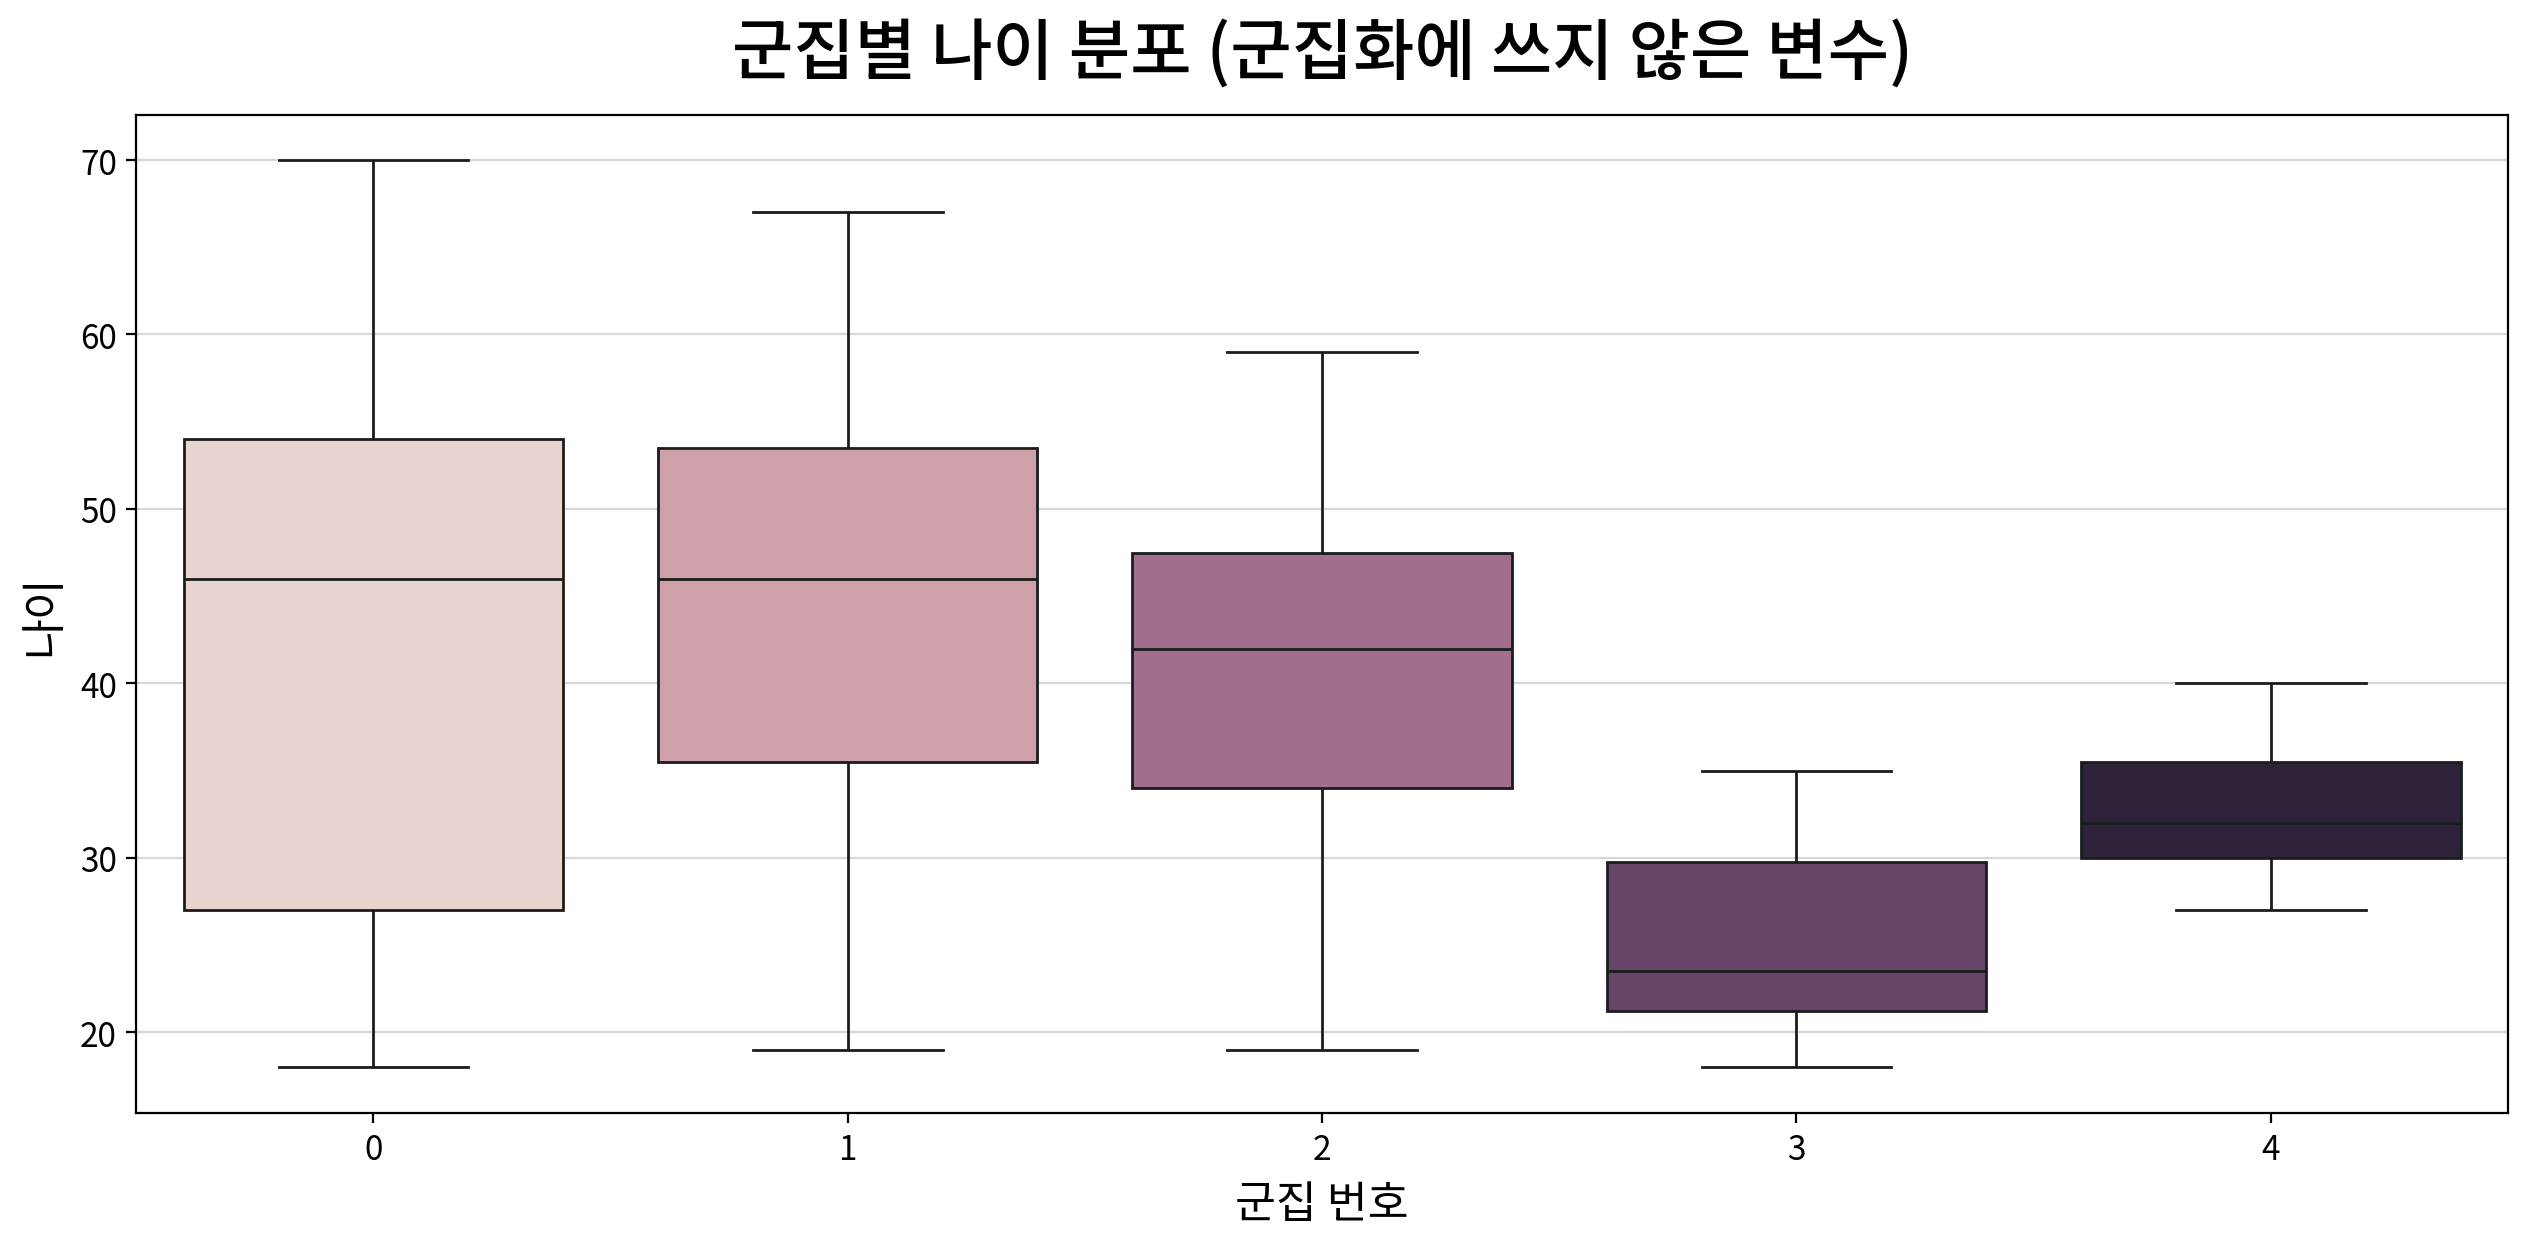

In [17]:
my_plot.boxplot(data=pdf, x="ClusterID", y="나이", hue="ClusterID", 
                title="군집별 나이 분포 (군집화에 쓰지 않은 변수)",
                xlabel="군집 번호", ylabel="나이")

#### 💡 인사이트

- **저소득 · 고지출** 군집이 눈에 띄게 젊다
- **고소득 · 고지출**(핵심 고객) 군집도 비교적 젊은 편이다
- 나머지 세 군집은 40대에 몰려 있다

> "젊은 고객은 소득과 무관하게 많이 쓴다"는 문장이 여기서 나온다.
> **군집화에 쓰지 않은 변수에서 나온 발견이라 근거가 더 강하다.**

### 5. 범주형 변수 비율 확인

- `성별` 의 최빈값은 대부분의 군집에서 같은 값이 나온다. 
- 이럴 때는 **구성비를 함께** 봐야 차이가 보인다.

In [ ]:
# 군집 × 성별 교차표
ct = crosstab(pdf["ClusterID"], pdf["성별"])
display(ct)

# 비율로 환산 (행 기준 %)
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

성별,Female,Male
ClusterID,,
0,48,33
1,14,9
2,16,19
3,13,9
4,21,18


성별,Female,Male
ClusterID,,
0,59.300,40.700
1,60.900,39.100
2,45.700,54.300
3,59.100,40.900
4,53.800,46.200


#### 💡 인사이트

- 전체 여성 비율은 **56%** 다. 대부분의 군집이 이 근처에 있다
- 그런데 **고소득 · 저지출 군집만 남성 비율이 더 높다**
- 최빈값 하나만 보면 "다 여성"으로 보이지만, **구성비를 보면 이 군집만 다르다**

> **이것이 `#01-[3]` 의 "분리력이 큰 변수만 고른다"는 기준을 실제로 적용해 본 것이다.**
> `성별` 은 분리력이 약한 변수다. 페르소나 표에 넣되 **주된 근거로 삼지는 않는다.**

## #05. 페르소나 분석 활용

### 1. 신규 고객은 어느 그룹일까?

신규 가입 고객이 어느 그룹에 속하는지 예측해 보자.

> ⚠️ **새 데이터도 반드시 학습 때와 똑같은 기준으로 스케일링해야 한다.**
> 그래서 앞에서 스케일러를 파일로 저장해 두었다.

In [ ]:
# 신규 고객 3명 (연수입, 지출점수)
new_data = [[70, 85],    # 소득도 높고 많이 쓴다
            [30, 20],    # 소득도 적고 적게 쓴다
            [88, 18]]    # 소득은 높은데 적게 쓴다

new_df = DataFrame(new_data, columns=df.columns)
new_df

,연수입,지출점수
0,70,85
1,30,20
2,88,18


### 2. 초기 분석과 동일한 스케일러 적용

In [ ]:
# 저장해 둔 스케일러를 불러와 똑같은 기준으로 변환
scaler = joblib.load("models/mall_scaler.pkl")
new_scaled = DataFrame(scaler.transform(new_df), columns=df.columns)

display(new_scaled)

# 어느 군집에 속하는지 예측
print("예측된 군집:", estimator.predict(new_scaled))

,연수입,지출점수
0,0.360,1.351
1,-1.166,-1.172
2,1.047,-1.250


예측된 군집: [4 1 2]


#### 💡 인사이트

- 첫 번째 고객은 **핵심 고객** 그룹에 배정되었을 것이다 → 가입 즉시 VIP 프로그램 안내
- 두 번째 고객은 **저관여** 그룹 → 비용이 큰 캠페인의 대상에서 제외
- 세 번째 고객은 **설득 대상** 그룹 → "왜 안 쓰는가"를 파악할 설문 대상

위의 `persona_df` 와 비교해 실제로 그렇게 배정됐는지 확인해 보자.

> **이것이 군집분석의 실무 활용법이다.**
> 한 번 그룹을 만들어 두면, 신규 고객이 들어올 때마다 **어느 그룹인지 바로 분류**해
> 그 그룹에 맞는 액션을 자동으로 연결할 수 있다.